# Reinforcement Learning for Domain-Specific LLMs: Healthcare/Medical

## Problem Statement

Recent advances in large-scale reinforcement learning (RL) have demonstrated strong gains in improving both the reasoning and task performance of large language models (LLMs), especially on domain-specific tasks with verifiable or structured outputs. This work extends RL-based training approaches to the **healthcare/medical domain**, designing a principled and novel RL methodology that enables a domain-specific LLM to achieve strong performance on medical question-answering tasks.

## Approach Overview

We propose a **multi-stage training pipeline** that combines Supervised Fine-Tuning (SFT) with Group Relative Policy Optimization (GRPO), using carefully designed reward signals tailored to medical reasoning. Our key contributions are:

1. **Embedding-based reward shaping**: Instead of relying solely on binary correctness signals, we use a **Mahalanobis distance** in the embedding space of a domain-specific biomedical encoder (`PubMedBERT`) to provide dense, continuous reward signals that capture semantic similarity between generated and reference explanations.

2. **Curriculum learning strategy**: We decompose the RL training into phases -- first teaching the model to produce well-formatted outputs (format compliance reward), then optimizing for semantic quality (embedding-based reward). This addresses the cold-start problem where a base model may not generate parseable outputs.

3. **SFT-to-GRPO transfer**: We investigate whether initializing GRPO from an SFT-finetuned model (rather than the base model) improves sample efficiency and final performance, combining the benefits of behavioral cloning with policy optimization.

We use **Qwen3-0.6B** as our base model and **PubMedQA** as the training/evaluation dataset, with parameter-efficient fine-tuning (LoRA) to keep the approach practical on consumer GPUs.

## 1. Approach & Methodology

### Why GRPO for Medical QA?

Group Relative Policy Optimization (GRPO) is a variant of policy optimization that, for each prompt, generates a **group of completions** and computes advantages relative to the group mean reward. This has several advantages for medical tasks:

- **Multi-path reasoning**: By generating multiple completions per prompt (we use $G=8$), the model explores diverse reasoning paths. The relative advantage formulation naturally encourages diversity while rewarding correctness.
- **No separate value network**: Unlike PPO, GRPO does not require a critic model, reducing memory overhead -- critical when working with limited GPU resources.
- **Dense reward compatibility**: GRPO's advantage normalization works well with continuous reward signals (like our embedding distance), not just sparse binary rewards.

### Reward Signals Directly from Data

We design three types of reward signals, each derived directly from the data without requiring a separate trained reward model:

1. **Answer correctness** $r_{\text{acc}}$: A binary signal -- 1 if the extracted answer matches the ground truth, 0 otherwise.
2. **Format compliance** $r_{\text{fmt}}$: A binary signal -- 1 if the output contains valid `<answer>` and `<long_answer>` XML tags, 0 otherwise.
3. **Embedding distance** $r_{\text{emb}}$: A continuous signal based on the negative Mahalanobis distance between the model's explanation and the reference explanation in the embedding space of a biomedical sentence encoder:

$$r_{\text{emb}}(\hat{y}, y) = -(e(\hat{y}) - e(y))^\top M (e(\hat{y}) - e(y))$$

where $e(\cdot)$ is the PubMedBERT encoder, $M$ is a positive semi-definite matrix (initialized to identity), and $y$ / $\hat{y}$ are the reference / generated explanations.

The embedding reward is particularly suited to healthcare because:
- Medical explanations can be correct in multiple phrasings; embedding similarity captures semantic equivalence beyond exact match.
- Using a **domain-specific encoder** (PubMedBERT, trained on biomedical literature) ensures the similarity metric is meaningful in the medical context.
- The Mahalanobis matrix $M$ can be set to $M = \frac{\lambda}{2} \Sigma^{-1}$ (inverse covariance of training embeddings), effectively whitening the embedding space and weighting dimensions by their informativeness.

## 2. Reward Model Design

### Reward Shaping for Effective Learning

A key challenge in RL for LLMs is **reward sparsity**: binary correctness rewards provide no gradient signal for partially correct outputs. Our embedding-based reward addresses this by providing a **continuous, dense signal** that rewards outputs proportionally to their semantic proximity to the reference.

### Adaptive Exploration via Curriculum

We use a **two-phase curriculum** to stabilize training:

- **Phase 1 (Format)**: The model is trained with only the format compliance reward. This ensures the model learns to produce structured outputs (`<answer>...</answer><long_answer>...</long_answer>`) before we optimize for content quality. Without this phase, the embedding reward would assign minimum penalty to unparseable outputs, creating a degenerate optimization landscape.

- **Phase 2 (Content)**: Once the model reliably produces well-formatted outputs, we switch to a weighted combination of format compliance and embedding distance rewards. The format reward acts as a **trajectory pruning** mechanism -- completions that don't follow the format receive zero reward and are effectively pruned from the advantage computation.

### Reward Weights

The total reward for GRPO is a weighted sum: $r = w_{\text{fmt}} \cdot r_{\text{fmt}} + w_{\text{content}} \cdot r_{\text{content}}$

where $r_{\text{content}}$ is either $r_{\text{acc}}$ or $r_{\text{emb}}$ depending on the variant. We use $w_{\text{fmt}} = 0.5$ throughout.

## 3. Multi-Path Reasoning Implementation

GRPO inherently implements multi-path reasoning through its **group generation** mechanism. For each input prompt, we generate $G=8$ independent completions using sampling. The relative advantage of each completion is computed as:

$$A_i = \frac{r_i - \mu_G}{\sigma_G}$$

where $\mu_G$ and $\sigma_G$ are the mean and standard deviation of rewards within the group. This normalization:

- **Encourages diversity**: Even if all completions are correct, those with better explanations (higher embedding reward) receive positive advantage.
- **Maintains consistency**: The KL penalty term ($\beta = 0.001$) prevents the policy from diverging too far from the base model, maintaining general reasoning capabilities.

Additionally, the prompt template asks the model to use a `<think>` block (leveraged during SFT), which encourages explicit chain-of-thought reasoning before producing the final answer.

## 4. Cold-Start Reasoning Enhancements

The **cold-start problem** is particularly acute in medical RL: a base model that has never seen medical QA may produce outputs that are completely unparseable, making reward computation impossible.

We address this with two complementary strategies:

1. **SFT warm-start**: Pre-training with SFT on the same dataset teaches the model the output format and basic medical reasoning patterns. The SFT phase uses **completion-only loss** (masking the prompt tokens), so the model learns to generate well-structured responses from the first training step.

2. **Format-first curriculum**: For the GRPO-only variants, the initial phase trains exclusively on format compliance. This is a simpler objective that the model can learn quickly, establishing a foundation for the more complex embedding-based reward.

3. **Minimum reward floor**: When the embedding reward encounters unparseable output, it assigns a fixed minimum reward ($-100$) rather than crashing. This provides a strong negative signal that steers the model away from degenerate outputs.

## 5. Software Stack

| Component | Library | Rationale |
|---|---|---|
| Base model | `Qwen/Qwen3-0.6B` | Lightweight yet capable; supports Flash Attention 2 |
| Parameter-efficient FT | `peft` (LoRA) | Reduces trainable parameters by ~99%; enables training on consumer GPUs |
| RL training | `trl` (GRPOTrainer, SFTTrainer) | Production-quality GRPO/SFT implementations with HF ecosystem integration |
| Embedding reward | `sentence-transformers` + `PubMedBERT` | Domain-specific biomedical embeddings for semantic similarity |
| Evaluation | `lm-eval-harness` | Standardized benchmarking (MMLU, MedMCQA) for reproducible comparison |
| Experiment tracking | TensorBoard | Lightweight logging integrated with TRL trainers |
| Inference | `transformers` + Flash Attention 2 | Fast batched generation with bf16 precision |

---

# Proof of Concept Implementation

Below we implement and compare 5 training variants:

| # | Method | Reward | Init |
|---|--------|--------|------|
| 1 | SFT | Cross-entropy (teacher forcing) | Base model |
| 2 | GRPO-AC | Format + Answer Correctness | Base model |
| 3 | GRPO-Emb | Format + Embedding Distance | Base model |
| 4 | GRPO-Curriculum | Phase 1: Format only; Phase 2: Format + Embedding | Base model |
| 5 | SFT + GRPO | Format + Embedding | SFT-finetuned model |

---

# References

[1] The dataset: https://huggingface.co/datasets/bigbio/pubmed_qa

[2] The embedding model: https://huggingface.co/NeuML/pubmedbert-base-embeddings-8M

[3] The embedding distance idea from a paper published by the author: https://openreview.net/forum?id=5P1F5sSFjN

[4] Another paper by the author with a theoretical analysis of the embedding distance reward: https://arxiv.org/pdf/2510.07624?

In [ ]:
import os
import re
import time
import glob as glob_module
import json
import subprocess
from typing import Any
from datetime import datetime
from pathlib import Path
from collections import Counter
import random

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from peft import LoraConfig, PeftModel
from datasets import load_dataset, Dataset
from transformers import AutoModelForCausalLM, AutoProcessor
from trl import GRPOTrainer, GRPOConfig, SFTTrainer, SFTConfig
from sentence_transformers import SentenceTransformer
from sentence_transformers.models import StaticEmbedding
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"

/mnt/data_2/abenechehab/nll_to_po/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/mnt/data_2/abenechehab/nll_to_po/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/mnt/data_2/abenechehab/nll_to_po/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWa

### Hyperparameters

All training hyperparameters are exposed here for easy experimentation.

In [ ]:
# ──────────────────────────────────────────────
# Global configuration
# ──────────────────────────────────────────────
MODEL_NAME = "Qwen/Qwen3-0.6B"
DATASET_NAME = "bigbio/pubmed_qa"
OUTPUT_DIR_ROOT = "logs"
REWARD_EMBEDDING_MODEL = "NeuML/pubmedbert-base-embeddings-8M"
LAMBDA = 0.001
MAX_COMPLETION_LENGTH = 1024
SAVE_STEPS = 20
SEED = 42

# ──────────────────────────────────────────────
# Per-method max_steps (set to -1 to use num_train_epochs instead)
# ──────────────────────────────────────────────
SFT_MAX_STEPS = 100  # SFT training steps
GRPO_AC_MAX_STEPS = 100  # GRPO answer correctness
GRPO_EMB_MAX_STEPS = 100  # GRPO embedding distance
GRPO_CUR_PHASE1_MAX_STEPS = 50  # Curriculum phase 1 (format)
GRPO_CUR_PHASE2_MAX_STEPS = 50  # Curriculum phase 2 (embedding)
GRPO_SFT_MAX_STEPS = 100  # GRPO on top of SFT

# ──────────────────────────────────────────────
# Evaluation settings
# ──────────────────────────────────────────────
TEST_SET_SIZE = 50  # Number of test samples for answer-correctness eval (set to -1 for full test set)
N_EVAL_CHECKPOINTS = 3  # Number of equally spaced checkpoints to evaluate per method

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
# ──────────────────────────────────────────────
# Prompt formatting and answer extraction
# ──────────────────────────────────────────────

SYSTEM_PROMPT = (
    "You are a medical expert. Given a clinical research abstract, "
    "answer the yes/no question and provide a one-sentence explanation."
)


def format_prompt(sample: dict) -> str:
    contexts = "\n\n".join(
        f"[{label}]\n{context}"
        for label, context in zip(sample["LABELS"], sample["CONTEXTS"])
    )
    prompt = f"""<question>
{sample["QUESTION"]}
</question>

<abstract>
{contexts}
</abstract>

Answer the question with exactly "yes" or "no", then provide a one-sentence explanation of your reasoning.

Respond in this exact format:
<answer>yes/no</answer>
<long_answer>One sentence explanation here.</long_answer>"""
    return prompt


def extract_answer(text: str) -> str | None:
    match = re.search(r"<answer>\s*(yes|no)\s*</answer>", text, re.IGNORECASE)
    return match.group(1).strip().lower() if match else None


def extract_long_answer(text: str) -> str | None:
    match = re.search(r"<long_answer>(.*?)</long_answer>", text, re.DOTALL)
    return match.group(1).strip() if match else None

In [4]:
# ──────────────────────────────────────────────
# Reward functions
# ──────────────────────────────────────────────


def answer_correctness_reward(
    completions: list[list[dict[str, str]]],
    answer: list[str],
    **kwargs: Any,
) -> list[float]:
    """Returns 1.0 if the extracted <answer> matches the ground truth, else 0.0."""
    rewards = []
    for completion, ground_truth in zip(completions, answer):
        text = completion[0]["content"]
        predicted = extract_answer(text)
        reward = (
            1.0
            if (predicted is not None and predicted == ground_truth.strip().lower())
            else 0.0
        )
        rewards.append(reward)
    return rewards


def format_compliance_reward(
    completions: list[list[dict[str, str]]],
    **kwargs: Any,
) -> list[float]:
    """Returns 1.0 if both <answer> and <long_answer> tags are present and non-empty, else 0.0."""
    rewards = []
    for completion in completions:
        text = completion[0]["content"]
        has_answer = extract_answer(text) is not None
        has_long_answer = extract_long_answer(text) is not None
        rewards.append(1.0 if (has_answer and has_long_answer) else 0.0)
    return rewards

In [5]:
# ──────────────────────────────────────────────
# Embedding-based reward (SentenceTransformer)
# ──────────────────────────────────────────────


class SentenceTransformerMahalanobisReward(nn.Module):
    def __init__(
        self,
        model_name: str = "google/embeddinggemma-300m",
        train_encoder: bool = False,
        train_matrix: bool = True,
        max_length: int = 2048,
    ):
        super().__init__()
        self.max_length = max_length
        if model_name == "NeuML/pubmedbert-base-embeddings-8M":
            static = StaticEmbedding.from_model2vec(model_name)
            self.model = SentenceTransformer(modules=[static])
        else:
            self.model = SentenceTransformer(model_name, trust_remote_code=True)
            self.model.max_seq_length = max_length

        if not train_encoder:
            for p in self.model.parameters():
                p.requires_grad = False

        hidden_size = self.model.get_sentence_embedding_dimension()
        self.matrix = nn.Parameter(torch.eye(hidden_size), requires_grad=train_matrix)

    def _device(self):
        return self.matrix.device

    def set_matrix(self, matrix: torch.Tensor, trainable: bool = False):
        hidden = self.model.get_sentence_embedding_dimension()
        assert matrix.shape == (hidden, hidden)
        self.matrix = nn.Parameter(matrix.to(self._device()), requires_grad=trainable)

    def encode(self, y, y_hat):
        if isinstance(y, str):
            y = [y]
        if isinstance(y_hat, str):
            y_hat = [y_hat]
        e_y = self.model.encode(
            y, convert_to_tensor=True, device=self._device(), show_progress_bar=False
        )
        e_y_hat = self.model.encode(
            y_hat,
            convert_to_tensor=True,
            device=self._device(),
            show_progress_bar=False,
        )
        return e_y, e_y_hat

    def forward(self, y, y_hat):
        e_y, e_y_hat = self.encode(y, y_hat)
        diff = e_y - e_y_hat
        return -torch.einsum("...i,ij,...j->...", diff, self.matrix, diff)


def embedding_reward_func_constructor_pubmedqa(
    model: str,
    U_star=None,
    pooling: str = "mean",
    verbose: int = 0,
    max_length: int = 2048,
    answer_only: bool = True,
    sentence_transformer: bool = False,
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    if sentence_transformer:
        embedder = SentenceTransformerMahalanobisReward(
            model_name=model,
            train_encoder=False,
            train_matrix=False,
            max_length=max_length,
        )
        min_reward = -100.0
    else:
        raise NotImplementedError("Set sentence_transformer=True for this demo")

    if U_star is not None:
        embedder.set_matrix(matrix=nn.Parameter(U_star))
    embedder.to(device)

    def reward_func(
        completions: list[list[dict[str, str]]],
        answer: list[str],
        long_answer: list[str],
        **kwargs,
    ) -> list[float]:
        rewards = []
        for completion, a, la in zip(completions, answer, long_answer):
            try:
                text = completion[0]["content"]
                predicted_answer = extract_answer(text)
                predicted_long = extract_long_answer(text)

                if predicted_answer is None:
                    rewards.append(min_reward)
                    continue

                if answer_only:
                    y_hat = predicted_answer
                    y = a.strip().lower()
                else:
                    if predicted_long is None:
                        rewards.append(min_reward)
                        continue
                    y_hat = predicted_long
                    y = la.strip()

                reward = embedder(y_hat=y_hat, y=y)
                rewards.append(reward.item())

            except Exception as e:
                if verbose > 0:
                    print(
                        f"completion: {completion}\nanswer: {a}\nlong_answer: {la}\nError: {e}"
                    )
                rewards.append(min_reward)

        return rewards

    return reward_func

In [6]:
# ──────────────────────────────────────────────
# Dataset preparation helpers
# ──────────────────────────────────────────────


def prepare_dataset(hf_dataset) -> Dataset:
    """Map raw HuggingFace dataset rows to prompt/answer pairs for GRPO."""

    def process(sample):
        return {
            "prompt": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": format_prompt(sample)},
            ],
            "answer": sample["final_decision"],
            "long_answer": sample["LONG_ANSWER"],
        }

    return hf_dataset.map(process, remove_columns=hf_dataset.column_names)


def format_sft_sample(sample: dict) -> dict:
    contexts = "\n\n".join(
        f"[{label}]\n{context}"
        for label, context in zip(sample["LABELS"], sample["CONTEXTS"])
    )
    user_content = f"""<question>
{sample["QUESTION"]}
</question>

<abstract>
{contexts}
</abstract>

Answer with "yes" or "no", then provide a one-sentence explanation.

Respond in this exact format:
<answer>yes/no</answer>
<long_answer>One sentence explanation here.</long_answer>"""

    assistant_content = (
        f"<think>\n{sample['LONG_ANSWER']}\n</think>\n"
        f"<answer>{sample['final_decision']}</answer>\n"
        f"<long_answer>{sample['LONG_ANSWER']}</long_answer>"
    )

    return {
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ],
        "completion": [
            {"role": "assistant", "content": assistant_content},
        ],
    }


def prepare_sft_dataset(hf_dataset, num_samples: int | None = None):
    if num_samples is not None:
        hf_dataset = hf_dataset.select(range(num_samples))
    hf_dataset = hf_dataset.filter(
        lambda x: x["final_decision"] is not None and x["LONG_ANSWER"] is not None
    )
    return hf_dataset.map(
        format_sft_sample,
        remove_columns=hf_dataset.column_names,
    )

In [36]:
# ──────────────────────────────────────────────
# TensorBoard log plotting helpers
# ──────────────────────────────────────────────


def load_tb_scalars(log_dir: str, tags: list[str]):
    log_path = Path(log_dir)

    event_files = list(log_path.glob("runs/*/events.out.tfevents.*"))
    if not event_files:
        raise FileNotFoundError(f"No TensorBoard event files found in {log_path}")

    ea = EventAccumulator(str(event_files[0]))
    ea.Reload()

    result = {}
    available = ea.Tags().get("scalars", [])

    for tag in tags:
        if tag in available:
            events = ea.Scalars(tag)
            result[tag] = (
                [e.step for e in events],
                [e.value for e in events],
            )

    return result


def plot_sft_metrics(output_dir: str):
    """Plot SFT training metrics: loss and mean_token_accuracy."""
    data = load_tb_scalars(output_dir, ["train/loss", "train/mean_token_accuracy"])
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    if "train/loss" in data:
        steps, values = data["train/loss"]
        axes[0].plot(steps, values)
        axes[0].set_xlabel("Step")
        axes[0].set_ylabel("Loss")
        axes[0].set_title("SFT Training Loss")
        axes[0].grid(True, alpha=0.3)

    if "train/mean_token_accuracy" in data:
        steps, values = data["train/mean_token_accuracy"]
        axes[1].plot(steps, values, color="tab:green")
        axes[1].set_xlabel("Step")
        axes[1].set_ylabel("Mean Token Accuracy")
        axes[1].set_title("SFT Mean Token Accuracy")
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_grpo_metrics(output_dir: str, title_prefix: str = "GRPO"):
    """Plot GRPO training metrics: loss and reward (mean +/- std)."""
    data = load_tb_scalars(
        output_dir, ["train/loss", "train/reward", "train/reward_std"]
    )
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    if "train/loss" in data:
        steps, values = data["train/loss"]
        axes[0].plot(steps, values)
        axes[0].set_xlabel("Step")
        axes[0].set_ylabel("Loss")
        axes[0].set_title(f"{title_prefix} Training Loss")
        axes[0].grid(True, alpha=0.3)

    if "train/reward" in data:
        steps, mean_vals = data["train/reward"]
        axes[1].plot(steps, mean_vals, label="mean reward")
        if "train/reward_std" in data:
            _, std_vals = data["train/reward_std"]
            mean_arr = np.array(mean_vals)
            std_arr = np.array(std_vals)
            axes[1].fill_between(
                steps,
                mean_arr - std_arr,
                mean_arr + std_arr,
                alpha=0.2,
                label="+/- 1 std",
            )
        axes[1].set_xlabel("Step")
        axes[1].set_ylabel("Reward")
        axes[1].set_title(f"{title_prefix} Reward")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [65]:
# ──────────────────────────────────────────────
# Checkpoint selection and evaluation helpers
# ──────────────────────────────────────────────

from tqdm import tqdm


def find_checkpoints(output_dir: str) -> list[str]:
    """Find all checkpoint directories sorted by step number."""
    checkpoint_dirs = sorted(
        glob_module.glob(os.path.join(output_dir, "checkpoint-*")),
        key=lambda x: int(x.split("-")[-1]),
    )
    checkpoint_dirs.append(output_dir)  # final model
    return checkpoint_dirs


def get_step_number(checkpoint_path: str) -> int:
    """Extract step number from checkpoint path."""
    basename = os.path.basename(checkpoint_path)
    if basename.startswith("checkpoint-"):
        return int(basename.split("-")[-1])
    return -1  # Final model


def select_n_checkpoints(
    checkpoint_list: list[tuple[int, str]], n: int = 3
) -> list[tuple[int, str]]:
    """Select n equally spaced checkpoints from a sorted list of (step, path) tuples."""
    if len(checkpoint_list) <= n:
        return checkpoint_list
    indices = np.linspace(0, len(checkpoint_list) - 1, n, dtype=int)
    return [checkpoint_list[i] for i in indices]


def evaluate_checkpoint(
    checkpoint_path: str,
    test_dataset,
    base_model_name: str = MODEL_NAME,
    max_new_tokens: int = 256,
    batch_size: int = 16,
) -> float:
    """Load a checkpoint and evaluate answer correctness on the test set."""
    model = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        attn_implementation="flash_attention_2",
        dtype="bfloat16",
        device_map="auto",
    )
    try:
        model = PeftModel.from_pretrained(model, checkpoint_path)
        model = model.merge_and_unload()
    except Exception:
        model = AutoModelForCausalLM.from_pretrained(
            checkpoint_path,
            attn_implementation="flash_attention_2",
            dtype="bfloat16",
            device_map="auto",
        )

    tokenizer = AutoProcessor.from_pretrained(base_model_name, padding_side="left")
    model.eval()

    # Subset test set if configured
    eval_dataset = test_dataset
    if TEST_SET_SIZE > 0 and TEST_SET_SIZE < len(test_dataset):
        eval_dataset = test_dataset.select(range(TEST_SET_SIZE))

    correct = 0
    total = 0

    for i in tqdm(range(0, len(eval_dataset), batch_size)):
        batch = eval_dataset[i : i + batch_size]
        prompts = batch["prompt"]
        answers = batch["answer"]

        texts = [
            tokenizer.apply_chat_template(p, tokenize=False, add_generation_prompt=True)
            for p in prompts
        ]
        inputs = tokenizer(
            texts, return_tensors="pt", padding=True, truncation=True, max_length=256
        ).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
            )

        for j, (output, gt) in enumerate(zip(outputs, answers)):
            generated = tokenizer.decode(
                output[inputs["input_ids"].shape[1] :], skip_special_tokens=True
            )
            predicted = extract_answer(generated)
            if predicted is not None and predicted == gt.strip().lower():
                correct += 1
            total += 1

    del model
    torch.cuda.empty_cache()

    return correct / total if total > 0 else 0.0


def collect_checkpoints_for_method(output_dir, max_steps: int) -> list[tuple[int, str]]:
    """Collect (step, path) pairs for a method, handling single or multi-phase dirs."""
    if isinstance(output_dir, list):
        all_checkpoints = []
        step_offset = 0
        per_phase_steps = [GRPO_CUR_PHASE1_MAX_STEPS, GRPO_CUR_PHASE2_MAX_STEPS]
        for idx, phase_dir in enumerate(output_dir):
            phase_max = per_phase_steps[idx] if idx < len(per_phase_steps) else 200
            for cp in find_checkpoints(phase_dir):
                step = get_step_number(cp)
                if step == -1:
                    step = step_offset + phase_max
                else:
                    step = step_offset + step
                all_checkpoints.append((step, cp))
            step_offset += phase_max
    else:
        all_checkpoints = []
        for cp in find_checkpoints(output_dir):
            step = get_step_number(cp)
            if step == -1:
                step = max_steps
            all_checkpoints.append((step, cp))
    return sorted(all_checkpoints, key=lambda x: x[0])

---

## 6. Dataset: PubMedQA

**PubMedQA** is a biomedical question-answering dataset derived from PubMed abstracts. Each sample contains:
- A **research question** derived from the article title
- **Abstract contexts** (labeled sections: BACKGROUND, METHODS, RESULTS, CONCLUSIONS)
- A **final decision** (yes/no/maybe) -- the answer to the question
- A **long answer** -- a one-sentence explanation

We chose PubMedQA because:
1. It has **verifiable outputs** (yes/no answers) suitable for RL reward computation
2. It requires **reasoning over scientific abstracts**, testing medical comprehension
3. The long-answer field provides **reference explanations** for our embedding-based reward
4. It is a well-established benchmark in biomedical NLP

In [38]:
raw_dataset = load_dataset(DATASET_NAME)
print(raw_dataset)
print(f"\nTrain split size: {len(raw_dataset['train'])}")
print(f"Columns: {raw_dataset['train'].column_names}")

DatasetDict({
    train: Dataset({
        features: ['QUESTION', 'CONTEXTS', 'LABELS', 'MESHES', 'YEAR', 'reasoning_required_pred', 'reasoning_free_pred', 'final_decision', 'LONG_ANSWER'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['QUESTION', 'CONTEXTS', 'LABELS', 'MESHES', 'YEAR', 'reasoning_required_pred', 'reasoning_free_pred', 'final_decision', 'LONG_ANSWER'],
        num_rows: 11269
    })
})

Train split size: 200000
Columns: ['QUESTION', 'CONTEXTS', 'LABELS', 'MESHES', 'YEAR', 'reasoning_required_pred', 'reasoning_free_pred', 'final_decision', 'LONG_ANSWER']


In [39]:
# Inspect a single example
example = raw_dataset["train"][0]
for key, value in example.items():
    print(f"--- {key} ---")
    if isinstance(value, list) and len(value) > 3:
        print(value[:3], "...")
    else:
        print(value)
    print()

--- QUESTION ---
Does neurobehavioral disinhibition predict initiation of substance use in children with prenatal cocaine exposure?

--- CONTEXTS ---
['In previous work we (Fisher et al., 2011) examined the emergence of neurobehavioral disinhibition (ND) in adolescents with prenatal substance exposure. We computed ND factor scores at three age points (8/9, 11 and 13/14 years) and found that both prenatal substance exposure and early adversity predicted ND. The purpose of the current study was to determine the association between these ND scores and initiation of substance use between ages 8 and 16 in this cohort as early initiation of substance use has been related to later substance use disorders. Our hypothesis was that prenatal cocaine exposure predisposes the child to ND, which, in turn, is associated with initiation of substance use by age 16.', "We studied 386 cocaine exposed and 517 unexposed children followed since birth in a longitudinal study. Five dichotomous variables were 

In [40]:
# Distribution of final_decision labels
labels = raw_dataset["train"]["final_decision"]
label_counts = Counter(labels)
print("Label distribution:")
for label, count in label_counts.most_common():
    print(f"  {label}: {count} ({100 * count / len(labels):.1f}%)")

Label distribution:
  yes: 185703 (92.9%)
  no: 14297 (7.1%)


In [41]:
# Preview the formatted prompt
print("=== Formatted prompt ===")
print(format_prompt(raw_dataset["train"][0]))

=== Formatted prompt ===
<question>
Does neurobehavioral disinhibition predict initiation of substance use in children with prenatal cocaine exposure?
</question>

<abstract>
[BACKGROUND]
In previous work we (Fisher et al., 2011) examined the emergence of neurobehavioral disinhibition (ND) in adolescents with prenatal substance exposure. We computed ND factor scores at three age points (8/9, 11 and 13/14 years) and found that both prenatal substance exposure and early adversity predicted ND. The purpose of the current study was to determine the association between these ND scores and initiation of substance use between ages 8 and 16 in this cohort as early initiation of substance use has been related to later substance use disorders. Our hypothesis was that prenatal cocaine exposure predisposes the child to ND, which, in turn, is associated with initiation of substance use by age 16.

[METHODS]
We studied 386 cocaine exposed and 517 unexposed children followed since birth in a longitud

### Data Preparation

We prepare two versions of the dataset:
- **GRPO format**: prompt (chat messages) + answer (ground truth) + long_answer (reference explanation)
- **SFT format**: prompt (chat messages) + completion (assistant response with `<think>`, `<answer>`, `<long_answer>` blocks)

In [31]:
# GRPO dataset
grpo_dataset = prepare_dataset(raw_dataset["train"])
grpo_split = grpo_dataset.train_test_split(test_size=0.1, seed=SEED)
grpo_train = grpo_split["train"]
grpo_test = grpo_split["test"]
print(f"GRPO train: {len(grpo_train)}, test: {len(grpo_test)}")

GRPO train: 180000, test: 20000


In [32]:
# SFT dataset
sft_dataset = prepare_sft_dataset(raw_dataset["train"])
sft_split = sft_dataset.train_test_split(test_size=0.1, seed=SEED)
sft_train = sft_split["train"]
sft_test = sft_split["test"]
print(f"SFT train: {len(sft_train)}, test: {len(sft_test)}")

SFT train: 180000, test: 20000


---

## 7. Experiment 1: Supervised Fine-Tuning (SFT)

SFT serves as both a **baseline** and a **warm-start** for later GRPO experiments. We fine-tune using LoRA on the attention projection layers (`k_proj`, `q_proj`, `v_proj`) with **completion-only loss** -- the model only learns to predict the assistant's response, not the prompt tokens.

The SFT target response includes a `<think>` block containing the reference long answer, followed by structured `<answer>` and `<long_answer>` tags. This teaches the model both the reasoning pattern and the output format simultaneously.

In [33]:
sft_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    attn_implementation="flash_attention_2",
    dtype="bfloat16",
    use_cache=True,
    device_map="auto",
)
sft_tokenizer = AutoProcessor.from_pretrained(MODEL_NAME, padding_side="left")

In [34]:
timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
sft_output_dir = f"{OUTPUT_DIR_ROOT}/{MODEL_NAME.split('/')[-1]}/{DATASET_NAME.split('/')[-1]}/[peft]trl-sft"
os.makedirs(sft_output_dir, exist_ok=True)

sft_peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["k_proj", "q_proj", "v_proj"],
)

sft_training_args = SFTConfig(
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=10,
    max_steps=SFT_MAX_STEPS,
    learning_rate=5e-5,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    logging_steps=10,
    report_to="tensorboard",
    save_steps=SAVE_STEPS,
    output_dir=sft_output_dir,
    max_length=2048,
    gradient_checkpointing=False,
    push_to_hub=False,
    completion_only_loss=True,
    packing=False,
)

sft_trainer = SFTTrainer(
    model=sft_model,
    args=sft_training_args,
    train_dataset=sft_train,
    peft_config=sft_peft_config,
)

print(f"SFT output dir: {sft_output_dir}")

SFT output dir: logs/Qwen3-0.6B/pubmed_qa/[peft]trl-sft


In [ ]:
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

torch.cuda.synchronize()
t0 = time.time()

sft_trainer_stats = sft_trainer.train()

torch.cuda.synchronize()
t1 = time.time()
print(f"Total SFT training time: {round(t1 - t0, 2)} seconds.")

used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
print(f"Peak reserved memory = {used_memory} GB.")

sft_trainer.save_model(sft_output_dir)

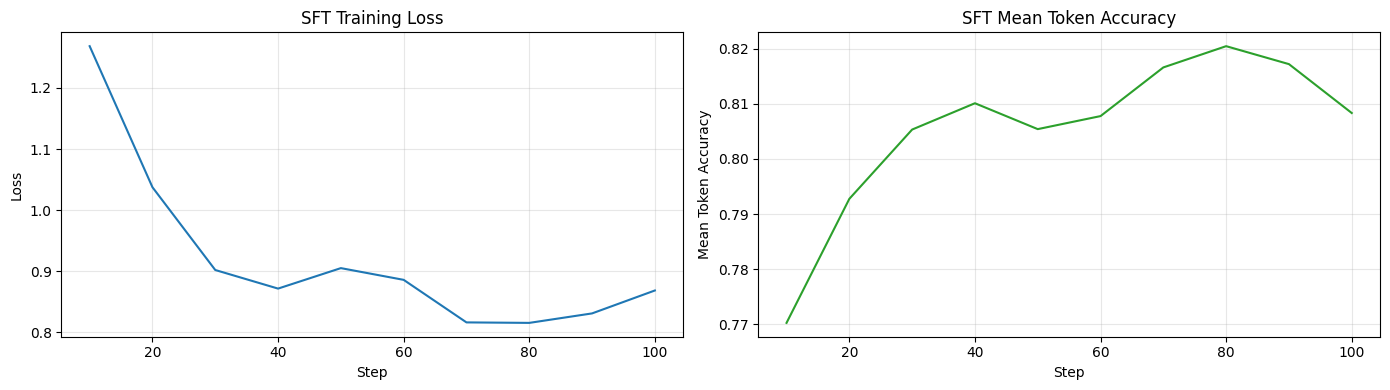

In [42]:
plot_sft_metrics(sft_output_dir)

In [43]:
del sft_model, sft_trainer
torch.cuda.empty_cache()

---

## 8. Experiment 2: GRPO with Answer Correctness Reward

This is the simplest GRPO variant: the reward is a weighted combination of **format compliance** and **answer correctness** (binary 0/1 match). This serves as the RL baseline -- a straightforward verifiable reward that is standard in the literature (similar to R1-Zero style training).

**Limitation**: The binary answer reward provides no signal about the *quality* of the explanation, and no gradient for "almost correct" answers. The model may learn to guess correctly without genuine reasoning.

In [44]:
grpo_ac_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    attn_implementation="flash_attention_2",
    dtype="bfloat16",
    use_cache=True,
    device_map="auto",
)
grpo_ac_tokenizer = AutoProcessor.from_pretrained(MODEL_NAME, padding_side="left")

In [45]:
grpo_ac_output_dir = f"{OUTPUT_DIR_ROOT}/{MODEL_NAME.split('/')[-1]}/{DATASET_NAME.split('/')[-1]}/grpo-answer-correctness"
os.makedirs(grpo_ac_output_dir, exist_ok=True)

grpo_ac_peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
)

grpo_ac_reward_funcs = [format_compliance_reward, answer_correctness_reward]
grpo_ac_reward_weights = [0.5, 0.5]

grpo_ac_training_args = GRPOConfig(
    do_eval=False,
    learning_rate=5e-5,
    num_train_epochs=1,
    max_steps=GRPO_AC_MAX_STEPS,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    max_completion_length=MAX_COMPLETION_LENGTH,
    max_prompt_length=256,
    num_generations=8,
    beta=LAMBDA,
    gradient_checkpointing=False,
    fp16=False,
    bf16=True,
    output_dir=grpo_ac_output_dir,
    logging_steps=1,
    save_steps=SAVE_STEPS,
    report_to="tensorboard",
    push_to_hub=False,
    log_completions=True,
    reward_weights=grpo_ac_reward_weights,
)

grpo_ac_trainer = GRPOTrainer(
    model=grpo_ac_model,
    processing_class=grpo_ac_tokenizer,
    reward_funcs=grpo_ac_reward_funcs,
    args=grpo_ac_training_args,
    train_dataset=grpo_train,
    peft_config=grpo_ac_peft_config,
)

print(f"GRPO (answer correctness) output dir: {grpo_ac_output_dir}")

GRPO (answer correctness) output dir: logs/Qwen3-0.6B/pubmed_qa/grpo-answer-correctness


<string>:191: FutureWarning: The `max_prompt_length` argument is deprecated and will be removed in version 0.28.0. You should instead filter your dataset before training to ensure that prompts do not exceed your desired length.


In [ ]:
torch.cuda.synchronize()
t0 = time.time()

grpo_ac_trainer.train()

torch.cuda.synchronize()
t1 = time.time()
print(f"Total GRPO (answer correctness) training time: {round(t1 - t0, 2)} seconds.")

grpo_ac_trainer.save_model(grpo_ac_output_dir)

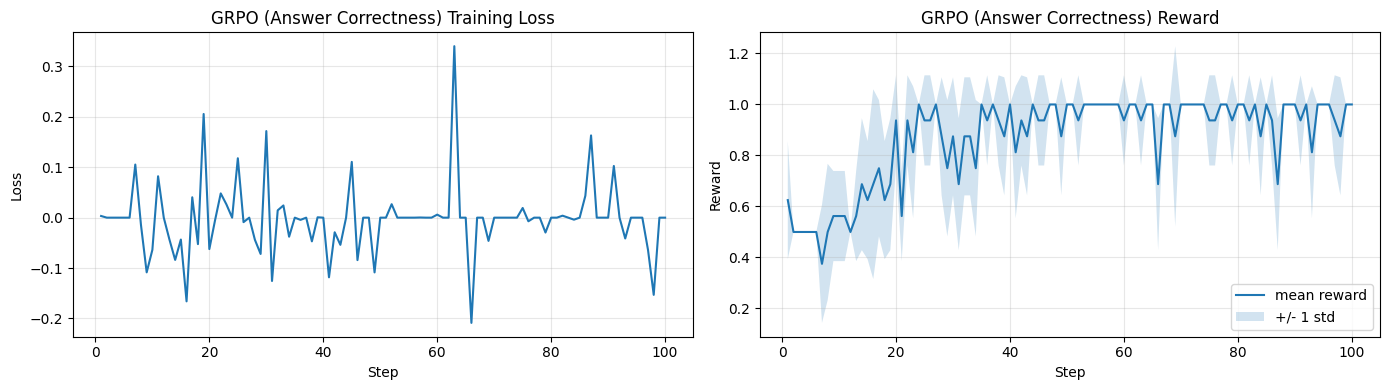

In [46]:
plot_grpo_metrics(grpo_ac_output_dir, title_prefix="GRPO (Answer Correctness)")

In [47]:
del grpo_ac_model, grpo_ac_trainer
torch.cuda.empty_cache()

---

## 9. Experiment 3: GRPO with Embedding Distance Reward

Here we replace the binary answer correctness reward with our **embedding-based distance reward**. The intuition is that instead of just checking whether the answer token ("yes"/"no") is correct, we measure how semantically close the model's *explanation* is to the reference explanation in the embedding space of a biomedical encoder.

This provides a **denser reward signal**: two explanations that convey similar medical reasoning will receive similar rewards, even if they use different words. The reward is:

$$r_{\text{emb}} = -\|e(\hat{y}) - e(y)\|_M^2$$

where $M = I$ (identity matrix) in this experiment. The embedding model is `NeuML/pubmedbert-base-embeddings-8M`, a lightweight PubMedBERT variant specifically trained for biomedical text similarity.

In [48]:
grpo_emb_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    attn_implementation="flash_attention_2",
    dtype="bfloat16",
    use_cache=True,
    device_map="auto",
)
grpo_emb_tokenizer = AutoProcessor.from_pretrained(MODEL_NAME, padding_side="left")

In [49]:
grpo_emb_output_dir = f"{OUTPUT_DIR_ROOT}/{MODEL_NAME.split('/')[-1]}/{DATASET_NAME.split('/')[-1]}/grpo-embedding"
os.makedirs(grpo_emb_output_dir, exist_ok=True)

grpo_emb_peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
)

embedding_reward_fn = embedding_reward_func_constructor_pubmedqa(
    model=REWARD_EMBEDDING_MODEL,
    U_star=None,
    pooling="cls",
    max_length=MAX_COMPLETION_LENGTH + 256,
    answer_only=False,
    sentence_transformer=True,
)

FORMAT_WEIGHT = 0.5
grpo_emb_reward_funcs = [format_compliance_reward, embedding_reward_fn]
grpo_emb_reward_weights = [FORMAT_WEIGHT, 1.0 - FORMAT_WEIGHT]

grpo_emb_training_args = GRPOConfig(
    do_eval=False,
    learning_rate=5e-5,
    num_train_epochs=1,
    max_steps=GRPO_EMB_MAX_STEPS,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    max_completion_length=MAX_COMPLETION_LENGTH,
    max_prompt_length=256,
    num_generations=8,
    beta=LAMBDA,
    gradient_checkpointing=False,
    fp16=False,
    bf16=True,
    output_dir=grpo_emb_output_dir,
    logging_steps=1,
    save_steps=SAVE_STEPS,
    report_to="tensorboard",
    push_to_hub=False,
    log_completions=True,
    reward_weights=grpo_emb_reward_weights,
)

grpo_emb_trainer = GRPOTrainer(
    model=grpo_emb_model,
    processing_class=grpo_emb_tokenizer,
    reward_funcs=grpo_emb_reward_funcs,
    args=grpo_emb_training_args,
    train_dataset=grpo_train,
    peft_config=grpo_emb_peft_config,
)

print(f"GRPO (embedding) output dir: {grpo_emb_output_dir}")

GRPO (embedding) output dir: logs/Qwen3-0.6B/pubmed_qa/grpo-embedding


<string>:191: FutureWarning: The `max_prompt_length` argument is deprecated and will be removed in version 0.28.0. You should instead filter your dataset before training to ensure that prompts do not exceed your desired length.


In [ ]:
torch.cuda.synchronize()
t0 = time.time()

grpo_emb_trainer.train()

torch.cuda.synchronize()
t1 = time.time()
print(f"Total GRPO (embedding) training time: {round(t1 - t0, 2)} seconds.")

grpo_emb_trainer.save_model(grpo_emb_output_dir)

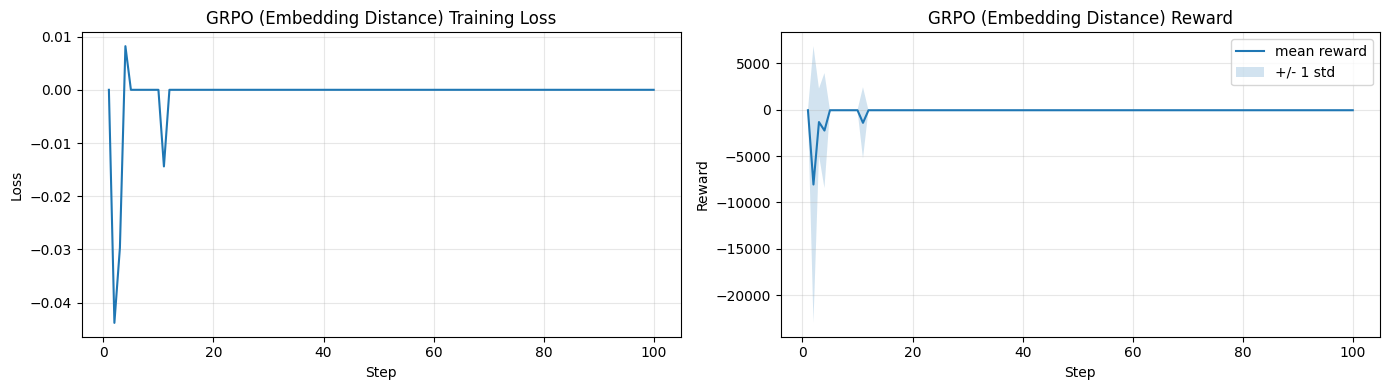

In [50]:
plot_grpo_metrics(grpo_emb_output_dir, title_prefix="GRPO (Embedding Distance)")

In [51]:
del grpo_emb_model, grpo_emb_trainer, embedding_reward_fn
torch.cuda.empty_cache()

---

## 10. Experiment 4: GRPO Curriculum (Format then Embedding)

This experiment tests our **curriculum learning** hypothesis: by first training the model to produce well-formatted outputs (Phase 1), we create a better starting point for the more complex embedding-based optimization (Phase 2).

**Phase 1** uses only the format compliance reward for the first half of training. The model learns to reliably produce `<answer>` and `<long_answer>` tags.

**Phase 2** loads the Phase 1 model (merging the LoRA weights), applies a fresh LoRA adapter, and trains with the embedding distance reward. Since the model already produces parseable outputs, the embedding reward function can provide meaningful gradients from the start.

This is our **cold-start mitigation strategy**: rather than hoping the base model produces formatted outputs by chance, we explicitly teach formatting first.

In [52]:
grpo_cur_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    attn_implementation="flash_attention_2",
    dtype="bfloat16",
    use_cache=True,
    device_map="auto",
)
grpo_cur_tokenizer = AutoProcessor.from_pretrained(MODEL_NAME, padding_side="left")

In [55]:
# ── Phase 1: Format reward only ──
grpo_cur_output_dir = f"{OUTPUT_DIR_ROOT}/{MODEL_NAME.split('/')[-1]}/{DATASET_NAME.split('/')[-1]}/grpo-curriculum"
grpo_cur_phase1_dir = f"{grpo_cur_output_dir}/phase1-format"
os.makedirs(grpo_cur_phase1_dir, exist_ok=True)

grpo_cur_peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
)

grpo_cur_phase1_args = GRPOConfig(
    do_eval=False,
    learning_rate=5e-5,
    num_train_epochs=1,
    max_steps=GRPO_CUR_PHASE1_MAX_STEPS,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    max_completion_length=MAX_COMPLETION_LENGTH,
    max_prompt_length=256,
    num_generations=8,
    beta=LAMBDA,
    gradient_checkpointing=False,
    fp16=False,
    bf16=True,
    output_dir=grpo_cur_phase1_dir,
    logging_steps=1,
    save_steps=SAVE_STEPS,
    report_to="tensorboard",
    push_to_hub=False,
    log_completions=True,
    reward_weights=[1.0],
)

grpo_cur_phase1_trainer = GRPOTrainer(
    model=grpo_cur_model,
    processing_class=grpo_cur_tokenizer,
    reward_funcs=[format_compliance_reward],
    args=grpo_cur_phase1_args,
    train_dataset=grpo_train,
    peft_config=grpo_cur_peft_config,
)

print(f"Curriculum phase 1 output dir: {grpo_cur_phase1_dir}")

Curriculum phase 1 output dir: logs/Qwen3-0.6B/pubmed_qa/grpo-curriculum/phase1-format


<string>:191: FutureWarning: The `max_prompt_length` argument is deprecated and will be removed in version 0.28.0. You should instead filter your dataset before training to ensure that prompts do not exceed your desired length.
/mnt/data_2/abenechehab/nll_to_po/.venv/lib/python3.12/site-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/mnt/data_2/abenechehab/nll_to_po/.venv/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:282: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [ ]:
torch.cuda.synchronize()
t0 = time.time()

grpo_cur_phase1_trainer.train()

torch.cuda.synchronize()
t1 = time.time()
print(f"Curriculum phase 1 training time: {round(t1 - t0, 2)} seconds.")

grpo_cur_phase1_trainer.save_model(grpo_cur_phase1_dir)

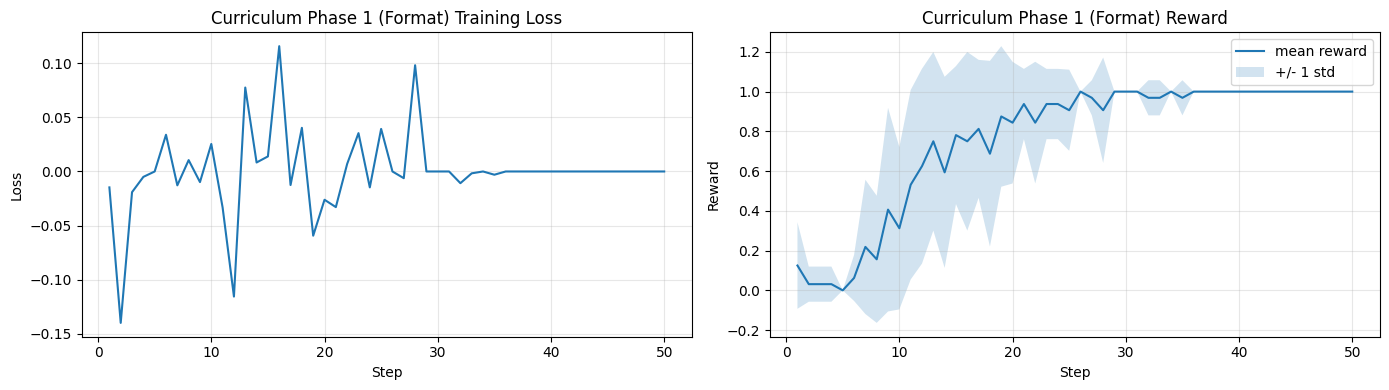

In [56]:
plot_grpo_metrics(grpo_cur_phase1_dir, title_prefix="Curriculum Phase 1 (Format)")

In [57]:
del grpo_cur_phase1_trainer
torch.cuda.empty_cache()

In [58]:
# ── Phase 2: Embedding reward on the phase-1 model ──
grpo_cur_phase2_dir = f"{grpo_cur_output_dir}/phase2-embedding"
os.makedirs(grpo_cur_phase2_dir, exist_ok=True)

grpo_cur_phase2_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    attn_implementation="flash_attention_2",
    dtype="bfloat16",
    use_cache=True,
    device_map="auto",
)
grpo_cur_phase2_model = PeftModel.from_pretrained(
    grpo_cur_phase2_model, grpo_cur_phase1_dir
)
grpo_cur_phase2_model = grpo_cur_phase2_model.merge_and_unload()
grpo_cur_phase2_tokenizer = AutoProcessor.from_pretrained(
    MODEL_NAME, padding_side="left"
)

embedding_reward_fn_cur = embedding_reward_func_constructor_pubmedqa(
    model=REWARD_EMBEDDING_MODEL,
    U_star=None,
    pooling="cls",
    max_length=MAX_COMPLETION_LENGTH + 256,
    answer_only=False,
    sentence_transformer=True,
)

grpo_cur_phase2_peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
)

FORMAT_WEIGHT = 0.5
grpo_cur_phase2_args = GRPOConfig(
    do_eval=False,
    learning_rate=5e-5,
    num_train_epochs=1,
    max_steps=GRPO_CUR_PHASE2_MAX_STEPS,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    max_completion_length=MAX_COMPLETION_LENGTH,
    max_prompt_length=256,
    num_generations=8,
    beta=LAMBDA,
    gradient_checkpointing=False,
    fp16=False,
    bf16=True,
    output_dir=grpo_cur_phase2_dir,
    logging_steps=1,
    save_steps=SAVE_STEPS,
    report_to="tensorboard",
    push_to_hub=False,
    log_completions=True,
    reward_weights=[FORMAT_WEIGHT, 1.0 - FORMAT_WEIGHT],
)

grpo_cur_phase2_trainer = GRPOTrainer(
    model=grpo_cur_phase2_model,
    processing_class=grpo_cur_phase2_tokenizer,
    reward_funcs=[format_compliance_reward, embedding_reward_fn_cur],
    args=grpo_cur_phase2_args,
    train_dataset=grpo_train,
    peft_config=grpo_cur_phase2_peft_config,
)

print(f"Curriculum phase 2 output dir: {grpo_cur_phase2_dir}")

Curriculum phase 2 output dir: logs/Qwen3-0.6B/pubmed_qa/grpo-curriculum/phase2-embedding


<string>:191: FutureWarning: The `max_prompt_length` argument is deprecated and will be removed in version 0.28.0. You should instead filter your dataset before training to ensure that prompts do not exceed your desired length.
/mnt/data_2/abenechehab/nll_to_po/.venv/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:282: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [ ]:
torch.cuda.synchronize()
t0 = time.time()

grpo_cur_phase2_trainer.train()

torch.cuda.synchronize()
t1 = time.time()
print(f"Curriculum phase 2 training time: {round(t1 - t0, 2)} seconds.")

grpo_cur_phase2_trainer.save_model(grpo_cur_phase2_dir)

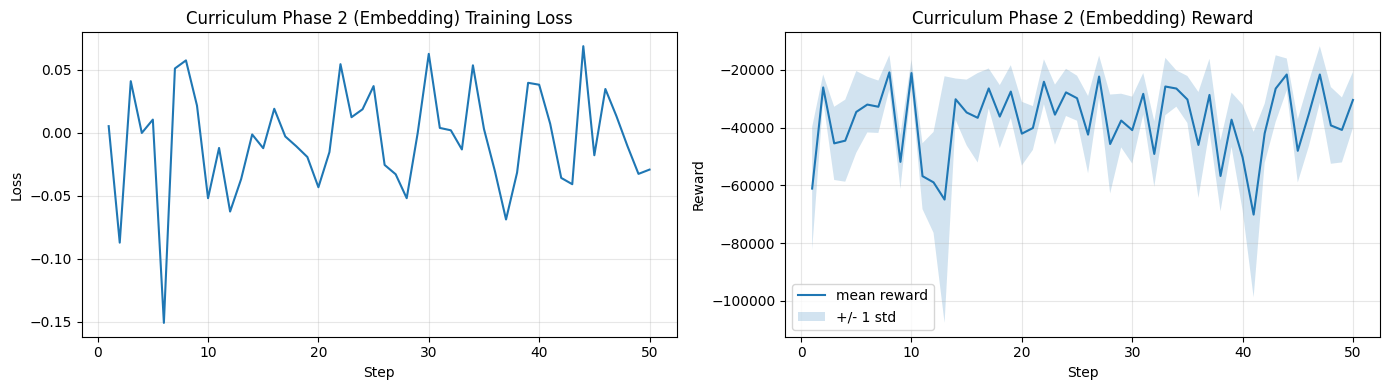

In [59]:
plot_grpo_metrics(grpo_cur_phase2_dir, title_prefix="Curriculum Phase 2 (Embedding)")

In [60]:
del (
    grpo_cur_model,
    grpo_cur_phase2_model,
    grpo_cur_phase2_trainer,
    embedding_reward_fn_cur,
)
torch.cuda.empty_cache()

---

## 11. Experiment 5: SFT then GRPO

This experiment combines the strengths of both approaches: we first **warm-start** with SFT (teaching the model format and basic medical reasoning via teacher forcing), then apply **GRPO with embedding reward** to further optimize the policy beyond what imitation learning can achieve.

The hypothesis is that SFT provides a much better initialization than the base model or format-only curriculum:
- The model already produces well-formatted outputs (no cold-start problem)
- It has learned basic medical reasoning patterns from the reference answers
- GRPO can then refine the policy by exploring alternative reasoning paths that the SFT data didn't cover

This mirrors the common practice in RLHF pipelines (SFT -> RL) adapted to our medical domain.

In [61]:
grpo_sft_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    attn_implementation="flash_attention_2",
    dtype="bfloat16",
    use_cache=True,
    device_map="auto",
)
grpo_sft_model = PeftModel.from_pretrained(grpo_sft_model, sft_output_dir)
grpo_sft_model = grpo_sft_model.merge_and_unload()
grpo_sft_tokenizer = AutoProcessor.from_pretrained(MODEL_NAME, padding_side="left")

In [62]:
grpo_sft_output_dir = f"{OUTPUT_DIR_ROOT}/{MODEL_NAME.split('/')[-1]}/{DATASET_NAME.split('/')[-1]}/grpo-on-sft"
os.makedirs(grpo_sft_output_dir, exist_ok=True)

grpo_sft_peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
)

embedding_reward_fn_sft = embedding_reward_func_constructor_pubmedqa(
    model=REWARD_EMBEDDING_MODEL,
    U_star=None,
    pooling="cls",
    max_length=MAX_COMPLETION_LENGTH + 256,
    answer_only=False,
    sentence_transformer=True,
)

FORMAT_WEIGHT = 0.5
grpo_sft_reward_funcs = [format_compliance_reward, embedding_reward_fn_sft]
grpo_sft_reward_weights = [FORMAT_WEIGHT, 1.0 - FORMAT_WEIGHT]

grpo_sft_training_args = GRPOConfig(
    do_eval=False,
    learning_rate=5e-5,
    num_train_epochs=1,
    max_steps=GRPO_SFT_MAX_STEPS,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    max_completion_length=MAX_COMPLETION_LENGTH,
    max_prompt_length=256,
    num_generations=8,
    beta=LAMBDA,
    gradient_checkpointing=False,
    fp16=False,
    bf16=True,
    output_dir=grpo_sft_output_dir,
    logging_steps=1,
    save_steps=SAVE_STEPS,
    report_to="tensorboard",
    push_to_hub=False,
    log_completions=True,
    reward_weights=grpo_sft_reward_weights,
)

grpo_sft_trainer = GRPOTrainer(
    model=grpo_sft_model,
    processing_class=grpo_sft_tokenizer,
    reward_funcs=grpo_sft_reward_funcs,
    args=grpo_sft_training_args,
    train_dataset=grpo_train,
    peft_config=grpo_sft_peft_config,
)

print(f"GRPO on SFT output dir: {grpo_sft_output_dir}")

GRPO on SFT output dir: logs/Qwen3-0.6B/pubmed_qa/grpo-on-sft


<string>:191: FutureWarning: The `max_prompt_length` argument is deprecated and will be removed in version 0.28.0. You should instead filter your dataset before training to ensure that prompts do not exceed your desired length.
/mnt/data_2/abenechehab/nll_to_po/.venv/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:282: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [ ]:
torch.cuda.synchronize()
t0 = time.time()

grpo_sft_trainer.train()

torch.cuda.synchronize()
t1 = time.time()
print(f"Total GRPO-on-SFT training time: {round(t1 - t0, 2)} seconds.")

grpo_sft_trainer.save_model(grpo_sft_output_dir)

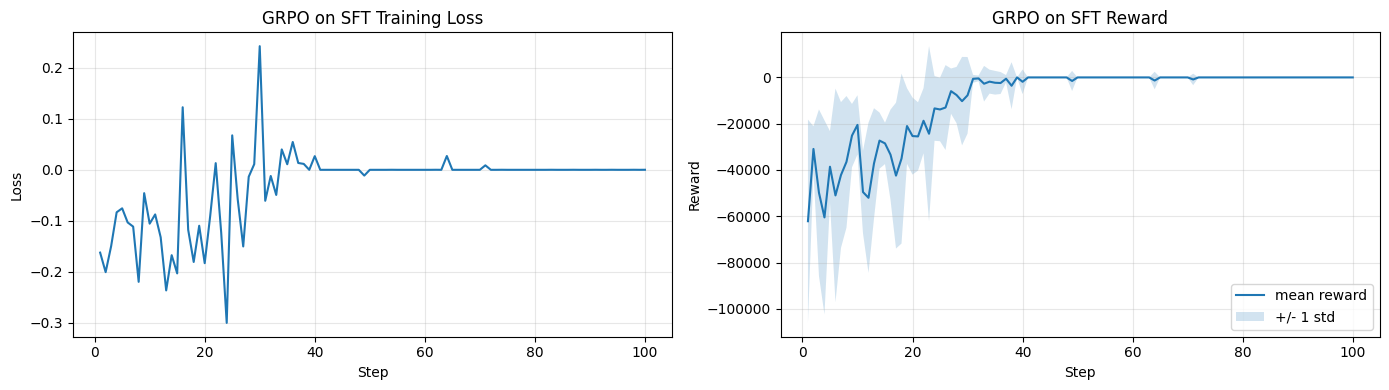

In [63]:
plot_grpo_metrics(grpo_sft_output_dir, title_prefix="GRPO on SFT")

In [64]:
del grpo_sft_model, grpo_sft_trainer, embedding_reward_fn_sft
torch.cuda.empty_cache()

---

## 12. Evaluation: Answer Correctness on Test Set

We evaluate **3 equally spaced checkpoints** from each method on the test set using the answer correctness metric. This gives us a view of how each method's performance evolves during training.

### Evaluation Metrics & KPIs

- **Answer Correctness Accuracy**: The primary KPI -- fraction of test samples where the extracted `<answer>` matches the ground truth. This is a strict metric that requires both correct format and correct answer.
- **Benchmark scores** (Hellaswag, MedMCQA): Secondary KPIs that measure whether domain-specific fine-tuning preserves or degrades general medical knowledge.

In [66]:
# Evaluate base model
print("Evaluating base model...")
base_model_accuracy = evaluate_checkpoint(
    checkpoint_path=MODEL_NAME,
    test_dataset=grpo_test,
    base_model_name=MODEL_NAME,
)
print(f"Base model accuracy: {base_model_accuracy:.4f}")

Evaluating base model...


100%|██████████| 4/4 [00:22<00:00,  5.54s/it]

Base model accuracy: 0.2000


In [69]:
# Define all methods, their output directories, and their max_steps
methods = {
    "SFT": (sft_output_dir, SFT_MAX_STEPS),
    "GRPO (Answer Correctness)": (grpo_ac_output_dir, GRPO_AC_MAX_STEPS),
    "GRPO (Embedding)": (grpo_emb_output_dir, GRPO_EMB_MAX_STEPS),
    "GRPO Curriculum (Format->Embed)": (
        [grpo_cur_phase1_dir, grpo_cur_phase2_dir],
        GRPO_CUR_PHASE1_MAX_STEPS + GRPO_CUR_PHASE2_MAX_STEPS,
    ),
    "GRPO on SFT": (grpo_sft_output_dir, GRPO_SFT_MAX_STEPS),
}

# Evaluate N_EVAL_CHECKPOINTS equally spaced checkpoints for each method
results = {}

for method_name, (output_dir, max_steps) in methods.items():
    print(f"\nEvaluating: {method_name}")

    all_checkpoints = collect_checkpoints_for_method(output_dir, max_steps)
    selected = select_n_checkpoints(all_checkpoints, n=N_EVAL_CHECKPOINTS)

    steps = []
    accuracies = []
    for step, cp in selected:
        print(f"  Step {step}: {os.path.basename(cp)}")
        acc = evaluate_checkpoint(cp, grpo_test)
        print(f"    Accuracy: {acc:.4f}")
        steps.append(step)
        accuracies.append(acc)

    results[method_name] = {"steps": steps, "accuracies": accuracies}


Evaluating: SFT
  Step 100: [peft]trl-sft


100%|██████████| 4/4 [00:22<00:00,  5.61s/it]


    Accuracy: 0.0600

Evaluating: GRPO (Answer Correctness)
  Step 20: checkpoint-20


100%|██████████| 4/4 [00:22<00:00,  5.54s/it]


    Accuracy: 0.2200
  Step 60: checkpoint-60


...

    Accuracy: 0.1600
  Step 60: checkpoint-60


100%|██████████| 4/4 [00:21<00:00,  5.47s/it]


    Accuracy: 0.2200
  Step 100: grpo-on-sft


100%|██████████| 4/4 [00:21<00:00,  5.46s/it]

    Accuracy: 0.1800


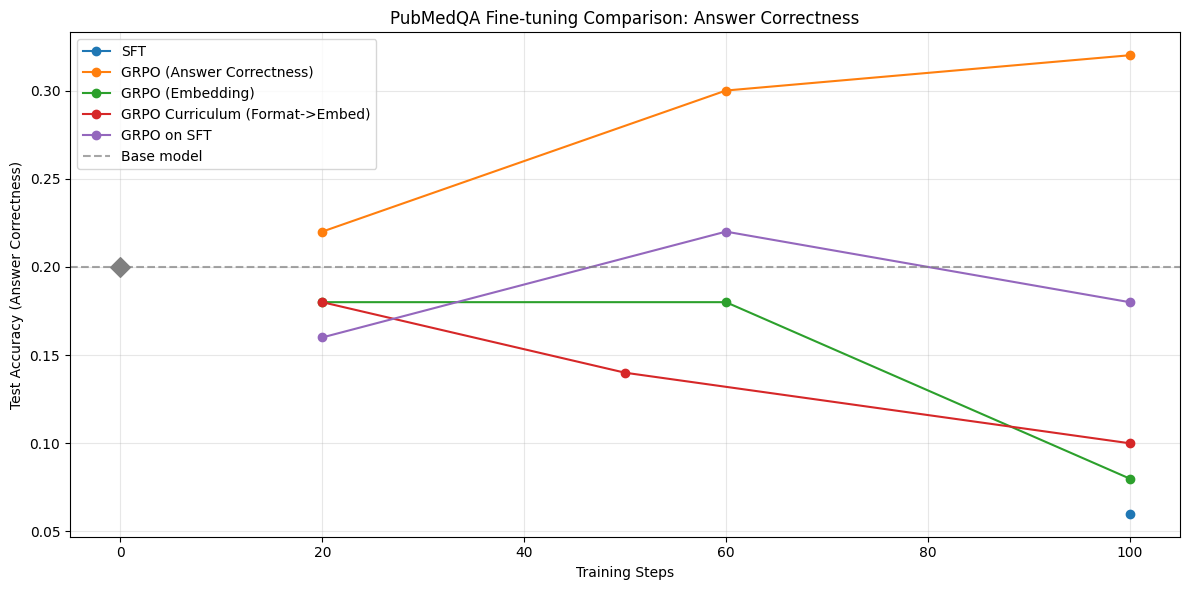

In [70]:
# Plot answer correctness comparison
plt.figure(figsize=(12, 6))

for method_name, data in results.items():
    plt.plot(data["steps"], data["accuracies"], marker="o", label=method_name)

plt.axhline(
    y=base_model_accuracy, color="gray", linestyle="--", alpha=0.7, label="Base model"
)
plt.scatter([0], [base_model_accuracy], color="gray", s=100, zorder=5, marker="D")

plt.xlabel("Training Steps")
plt.ylabel("Test Accuracy (Answer Correctness)")
plt.title("PubMedQA Fine-tuning Comparison: Answer Correctness")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pubmedqa_answer_correctness.pdf", dpi=150)
plt.show()

---

## 13. Evaluation: lm-eval-harness (Hellaswag & MedMCQA)

To measure whether fine-tuning preserves general knowledge, we evaluate on:
- **MMLU**: Massive Multitask Language Understanding -- a broad knowledge benchmark (took too long)
- **MedMCQA**: Medical multiple-choice QA -- a domain-specific benchmark
- **Hellaswag**: It tests whether a model can predict the most plausible conclusion to a story.

A good RL approach should improve domain performance **without catastrophic forgetting** of general capabilities.

In [79]:
def run_lm_eval(
    model_path: str, tasks: str = "mmlu,medmcqa", output_path: str = "lm_eval_results"
) -> dict:
    """Run lm-eval-harness on a model checkpoint and return parsed results."""

    result_dir = os.path.join(output_path, *Path(model_path).parts[1:])
    os.makedirs(result_dir, exist_ok=True)

    adapter_config = os.path.join(model_path, "adapter_config.json")
    if os.path.exists(adapter_config):
        model_args = f"pretrained={MODEL_NAME},peft={model_path},dtype=bfloat16"
    else:
        model_args = f"pretrained={model_path},dtype=bfloat16"

    cmd = [
        "lm_eval",
        "--model",
        "hf",
        "--model_args",
        model_args,
        "--tasks",
        tasks,
        "--batch_size",
        "auto",
        "--output_path",
        result_dir,
        "--log_samples",
    ]

    print(f"Running: {' '.join(cmd)}")
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
    if result.returncode != 0:
        print(f"STDERR: {result.stderr[-500:]}")

    scores = {}

    # Find timestamped result files
    result_files = glob_module.glob(
        os.path.join(result_dir, "**", "results_*.json"), recursive=True
    )

    if not result_files:
        print("No results_*.json files found.")
        return scores

    # Take most recent result file
    latest_file = max(result_files, key=os.path.getmtime)

    with open(latest_file) as f:
        data = json.load(f)

    for task_name, task_results in data.get("results", {}).items():
        acc = task_results.get("acc_norm,none", task_results.get("acc,none", None))
        if acc is not None:
            scores[task_name] = acc

    return scores

In [83]:
# Evaluate base model
print("=== Evaluating base model on MMLU & MedMCQA ===")
base_benchmark_scores = run_lm_eval(MODEL_NAME, tasks="hellaswag,medmcqa")
print(f"Base model scores: {base_benchmark_scores}")

=== Evaluating base model on MMLU & MedMCQA ===
Running: lm_eval --model hf --model_args pretrained=Qwen/Qwen3-0.6B,dtype=bfloat16 --tasks hellaswag,medmcqa --batch_size auto --output_path lm_eval_results/Qwen3-0.6B --log_samples
d=Qwen/Qwen3-0.6B,dtype=bfloat16), gen_kwargs: (None), limit: None, num_fewshot: None, batch_size: auto (64)
|  Tasks  |Version|Filter|n-shot| Metric |   |Value |   |Stderr|
|---------|-------|------|-----:|--------|---|-----:|---|-----:|
|hellaswag|      1|none  |     0|acc     |↑  |0.3754|±  |0.0048|
|         |       |none  |     0|acc_norm|↑  |0.4730|±  |0.0050|
|medmcqa  |Yaml   |none  |     0|acc     |↑  |0.3187|±  |0.0072|
|         |       |none  |     0|acc_norm|↑  |0.3187|±  |0.0072|


Base model scores: {'hellaswag': 0.47301334395538736, 'medmcqa': 0.31867081042314127}


In [84]:
# Evaluate N_EVAL_CHECKPOINTS equally spaced checkpoints on hellaswag & MedMCQA
benchmark_results = {}

for method_name, (output_dir, max_steps) in methods.items():
    print(f"\n{'=' * 60}")
    print(f"Evaluating: {method_name}")
    print(f"{'=' * 60}")

    all_checkpoints = collect_checkpoints_for_method(output_dir, max_steps)
    selected = select_n_checkpoints(all_checkpoints, n=N_EVAL_CHECKPOINTS)

    steps = []
    mmlu_scores = []
    medmcqa_scores = []

    for step, cp in selected:
        print(f"\n  Step {step}: {os.path.basename(cp)}")
        scores = run_lm_eval(cp, tasks="hellaswag,medmcqa")
        print(f"    Scores: {scores}")

        steps.append(step)
        mmlu_scores.append(scores.get("hellaswag", 0.0))
        medmcqa_scores.append(scores.get("medmcqa", 0.0))

    benchmark_results[method_name] = {
        "steps": steps,
        "hellaswag": mmlu_scores,
        "medmcqa": medmcqa_scores,
    }


Evaluating: SFT

  Step 100: [peft]trl-sft
Running: lm_eval --model hf --model_args pretrained=Qwen/Qwen3-0.6B,peft=logs/Qwen3-0.6B/pubmed_qa/[peft]trl-sft,dtype=bfloat16 --tasks hellaswag,medmcqa --batch_size auto --output_path lm_eval_results/Qwen3-0.6B/pubmed_qa/[peft]trl-sft --log_samples
_qa/[peft]trl-sft,dtype=bfloat16), gen_kwargs: (None), limit: None, num_fewshot: None, batch_size: auto (64)
|  Tasks  |Version|Filter|n-shot| Metric |   |Value |   |Stderr|
|---------|-------|------|-----:|--------|---|-----:|---|-----:|
|hellaswag|      1|none  |     0|acc     |↑  |0.3737|±  |0.0048|
|         |       |none  |     0|acc_norm|↑  |0.4710|±  |0.0050|
|medmcqa  |Yaml   |none  |     0|acc     |↑  |0.3270|±  |0.0073|
|         |       |none  |     0|acc_norm|↑  |0.3270|±  |0.0073|


No results_*.json files found.
    Scores: {}

Evaluating: GRPO (Answer Correctness)

  Step 20: checkpoint-20
Running: lm_eval --model hf --model_args pretrained=Qwen/Qwen3-0.6B,peft=logs/Qwen3-0.6B/pubm

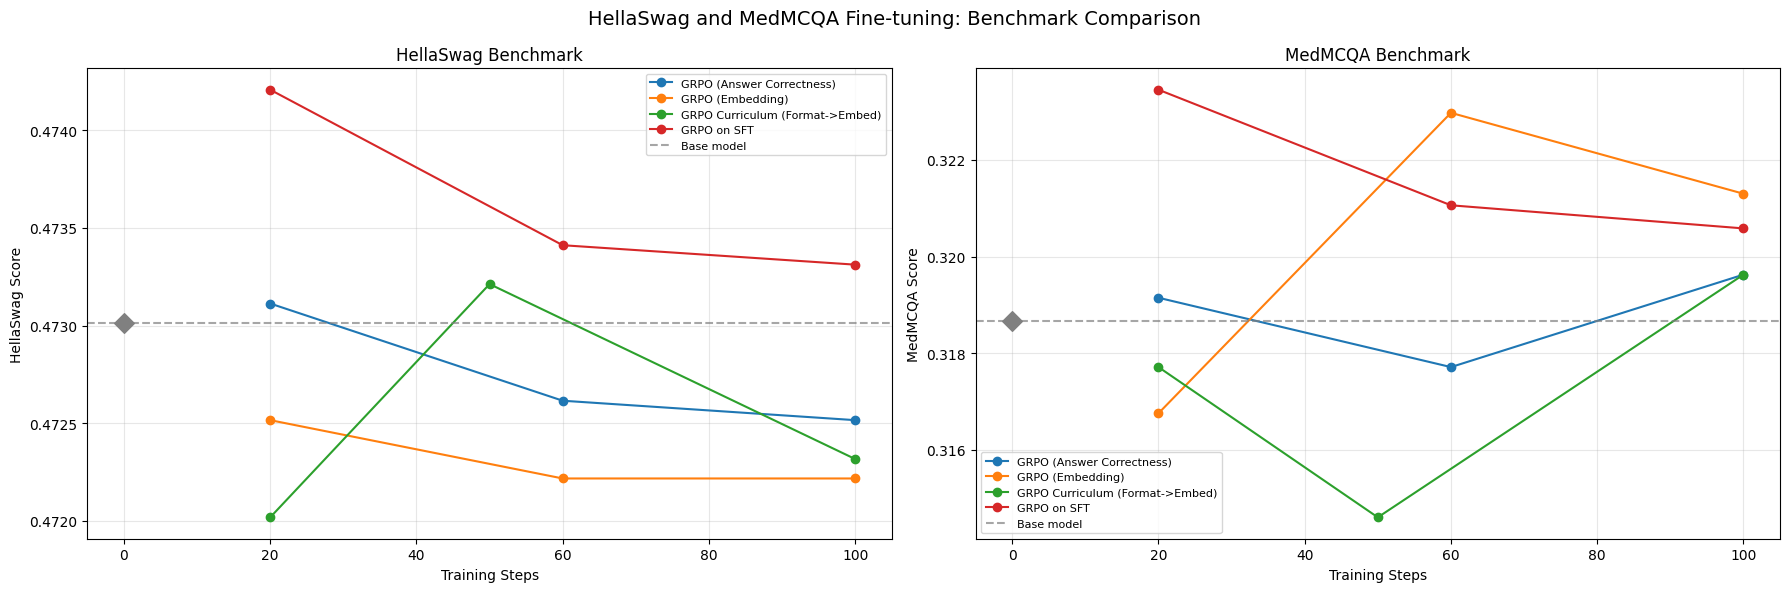

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Hellaswag
ax = axes[0]
for method_name, data in benchmark_results.items():
    ax.plot(data["steps"], data["hellaswag"], marker="o", label=method_name)
base_hellaswag = base_benchmark_scores.get("hellaswag", 0.0)
ax.axhline(
    y=base_hellaswag, color="gray", linestyle="--", alpha=0.7, label="Base model"
)
ax.scatter([0], [base_hellaswag], color="gray", s=100, zorder=5, marker="D")
ax.set_xlabel("Training Steps")
ax.set_ylabel("HellaSwag Score")
ax.set_title("HellaSwag Benchmark")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)

# MedMCQA
ax = axes[1]
for method_name, data in benchmark_results.items():
    ax.plot(data["steps"], data["medmcqa"], marker="o", label=method_name)
base_medmcqa = base_benchmark_scores.get("medmcqa", 0.0)
ax.axhline(y=base_medmcqa, color="gray", linestyle="--", alpha=0.7, label="Base model")
ax.scatter([0], [base_medmcqa], color="gray", s=100, zorder=5, marker="D")
ax.set_xlabel("Training Steps")
ax.set_ylabel("MedMCQA Score")
ax.set_title("MedMCQA Benchmark")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("HellaSwag and MedMCQA Fine-tuning: Benchmark Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("hellaswag_medmcqa_benchmarks.pdf", dpi=150, bbox_inches="tight")
plt.show()

## By: Abdelhakim Benechehab